# DX 704 Week 3 Project

This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

In [14]:
pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using seed 0 to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [15]:
# DO NOT CHANGE

import numpy as np

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low=1, high=10, size=self.num_arms)
        self.ps = self.rng.uniform(low=0.2, high=0.4, size=self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform()
        x *= self.rng.binomial(self.ns[arm], self.ps[arm])

        return x


In [16]:
bandit0 = BanditProblem(0)

In [17]:
bandit0.get_num_arms()

3

In [18]:
bandit0.get_reward(arm=0)

1.8255111545554434

arm 0: min=0.000 max=5.289 mean=0.797 frac_zero=0.166
arm 1: min=0.000 max=4.845 mean=0.620 frac_zero=0.267
arm 2: min=0.000 max=4.096 mean=0.918 frac_zero=0.104


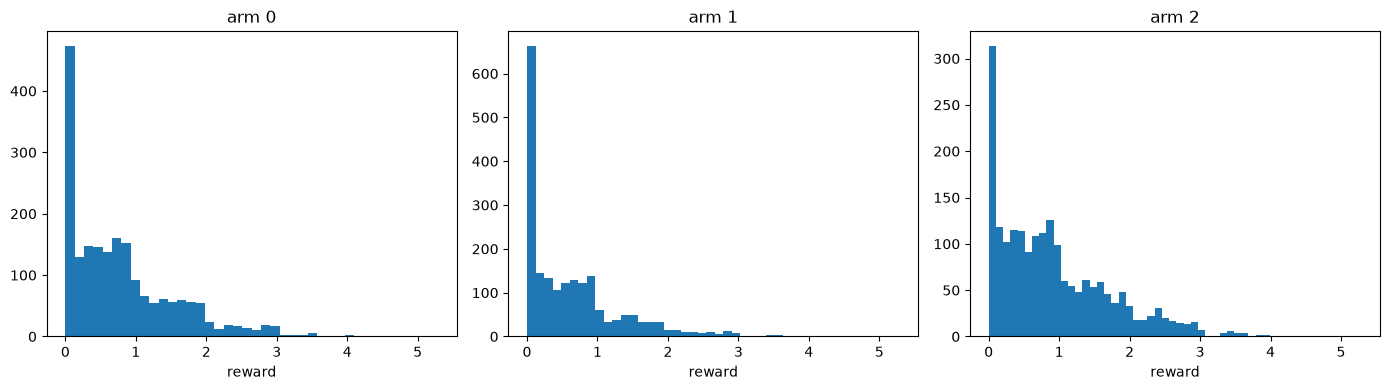

In [19]:
# YOUR CHANGES HERE

import matplotlib.pyplot as plt
import numpy as np

samples = {arm: np.array([bandit0.get_reward(arm) for _ in range(2000)])
           for arm in range(bandit0.get_num_arms())}

for arm, s in samples.items():
    print(f"arm {arm}: min={s.min():.3f} max={s.max():.3f} "
          f"mean={s.mean():.3f} frac_zero={(s == 0).mean():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for arm, ax in zip(samples, axes):
    ax.hist(samples[arm], bins=40)
    ax.set_title(f"arm {arm}")
    ax.set_xlabel("reward")
plt.tight_layout()
plt.show()

Based on your investigation, pick an appropriate bandit algorithm to implement from the algorithms covered this week.
Write a file "algorithm-choice.txt" that states your choice and give a single sentence justifying your choice and rejecting the alternatives.
Keep your explanation concise; you should be able to justify your choice solely based on the type of numbers observed, and whether those match the bandit algorithms that you have learned.

In [20]:
with open("algorithm-choice.txt", "w") as f:
    f.write(
        "Epsilon-greedy.\n"
        "The rewards are continuous non-negative values with a point mass at zero "
        "and a tail well above 1, so Beta-Bernoulli Thompson sampling (needs 0/1 "
        "rewards) and UCB1 (needs rewards bounded in a known [0,1] range) do not "
        "apply, while epsilon-greedy only needs sample means.\n"
    )

## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using seed 2026.

In [21]:
# YOUR CHANGES HERE

bandit = BanditProblem(2026)
K = bandit.get_num_arms()
T = 1000
epsilon = 0.1

rng = np.random.default_rng(42)
counts = np.zeros(K)
sums = np.zeros(K)
history = []

for arm in range(K):
    reward = bandit.get_reward(arm)
    counts[arm] += 1
    sums[arm] += reward
    history.append((arm, reward))

for t in range(K, T):
    if rng.uniform() < epsilon:
        arm = int(rng.integers(K))
    else:
        arm = int(np.argmax(sums / counts))
    reward = bandit.get_reward(arm)
    counts[arm] += 1
    sums[arm] += reward
    history.append((arm, reward))

print("counts:", counts)
print("estimated means:", sums / counts)

counts: [939.  37.  24.]
estimated means: [1.21695278 0.26768489 0.19663703]


Write a file "history.tsv" with columns action and reward in the order that the actions were taken.

In [22]:
# YOUR CHANGES HERE

import csv

with open("history.tsv", "w", newline="") as f:
    writer = csv.writer(f, delimiter="\t")
    writer.writerow(["action", "reward"])
    for action, reward in history:
        writer.writerow([action, reward])

Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the expected reward for each arm and write a file "actions.tsv" with the columns action, min_reward, mean_reward, max_reward.

In [23]:
# YOUR CHANGES HERE

import collections

rewards_by_arm = collections.defaultdict(list)
for action, reward in history:
    rewards_by_arm[action].append(reward)

stats = {}
for arm in range(K):
    r = np.array(rewards_by_arm[arm])
    stats[arm] = (r.min(), r.mean(), r.max())
    print(arm, len(r), stats[arm])

with open("actions.tsv", "w", newline="") as f:
    writer = csv.writer(f, delimiter="\t")
    writer.writerow(["action", "min_reward", "mean_reward", "max_reward"])
    for arm in range(K):
        lo, mu, hi = stats[arm]
        writer.writerow([arm, lo, mu, hi])

0 939 (np.float64(0.0), np.float64(1.216952783977073), np.float64(6.564312482579681))
1 37 (np.float64(0.0), np.float64(0.26768489359009656), np.float64(1.8804648564843633))
2 24 (np.float64(0.0), np.float64(0.1966370297837073), np.float64(0.9649857029319217))


Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Estimate the regret taking 1000 actions with the following strategies.

* uniform: Pick an arm uniformly at random.
* just-i: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* actual: This should match your output in part 2.

These estimates should be based on your previous action statistics; you should not use the true action values from the bandit code.

In [24]:
# YOUR CHANGES HERE

mean_reward = {arm: stats[arm][1] for arm in range(K)}
best_mean = max(mean_reward.values())

regrets = {}
regrets["uniform"] = T * (best_mean - np.mean([mean_reward[a] for a in range(K)]))
for arm in range(K):
    regrets[f"just-{arm}"] = T * (best_mean - mean_reward[arm])
regrets["actual"] = T * best_mean - sum(reward for _, reward in history)

for name, value in regrets.items():
    print(f"{name}: {value:.3f}")

uniform: 656.528
just-0: 0.000
just-1: 949.268
just-2: 1020.316
actual: 59.610


Write your results to a file "strategies.tsv" with the columns strategy and regret.

In [25]:
# YOUR CHANGES HERE

with open("strategies.tsv", "w", newline="") as f:
    writer = csv.writer(f, delimiter="\t")
    writer.writerow(["strategy", "regret"])
    for name, value in regrets.items():
        writer.writerow([name, value])

Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.